# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：土木工程
- 学号：052301235
- 姓名：罗晋源
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-yuanshao74
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要
本研究基于福州市二手房公开数据，运用Python进行数据清洗、描述性统计分析与可视化探索，旨在揭示二手房市场价格分布特征与影响因素。研究首先对原始数据进行清洗，包括格式统一、缺失值处理、字段拆分等操作；随后通过柱状图、散点图、箱线图等可视化手段，从区域差异、户型结构、面积与价格关系等维度展开分析。

主要结论如下：（1）福州二手房价格呈现显著的“核心-边缘”圈层结构，鼓楼区平均总价最高，闽侯、长乐等外围区域价格较低；（2）市场以中小户型（2室、3室）为流通主力，刚需特征明显；（3）面积与总价呈正相关关系，但大户型内部价格分化严重；（4）中间楼层普遍享有较高溢价，底层与顶层价格相对偏低。

本研究为购房者提供了区域选择与户型决策的数据参考，也为后续深入分析（如学区、地铁等隐性因素对房价的影响）奠定了基础。

## 2. 数据读取与分析目标

请说明本次分析的数据来源、字段大致含义，以及你计划围绕哪些问题展开分析。

In [45]:
%pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

In [47]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


1. 数据来源说明：

本次分析的数据来源于 ershoufang_list.csv 文件，该数据集包含了福州市多个行政区的二手房源挂牌信息。

2. 字段大致含义：

数据集中主要包含以下三类核心信息：

• 基本信息：包括“市区”、“所属小区”、“所属区域”，用于定位房源的地理位置。

• 房源特征：包括“户型”（几室几厅）、“面积”（房屋总面积）、“方位”（房屋朝向）、“楼层”（所在楼层高度）、“房龄”（房屋建成年份或新旧程度），这些字段描述了房屋的物理属性。

• 价格信息：包括“总价”（房屋总售价，单位通常为万元）、“单价”（每平方米的平均价格，单位通常为元/平方米），反映了市场的价格水平。

3. 计划围绕哪些问题展开分析（分析目标）：

为了全面挖掘福州二手房市场的特征，我计划围绕以下几个核心维度展开深入分析：

• 区域价格差异分析：对比鼓楼、台江、仓山、晋安等核心区域的均价与房源数量，探究“地段”对房价的影响。

• 房源特征与价格关联：分析不同户型、面积大小、房龄新旧以及房屋朝向如何共同影响房屋的总价和单价。

• 市场供需结构分析：统计主流户型（如几室几厅）的占比情况，了解市场上最受欢迎的房源类型及其价格区间。

• 面积与价格的量化关系：通过散点图等可视化手段，探究房屋面积与总价之间是否存在明显的线性增长规律。

## 3. 数据基本情况

请展示数据规模、字段名、数据类型、前几行样例，并用文字说明你对数据的初步理解。

In [48]:
# 数据规模
print("数据规模：")
df.shape

数据规模：


(11856, 18)

In [49]:
# 字段与数据类型
print("字段名与数据类型：")
df.info()

字段名与数据类型：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


In [50]:
# 描述性统计
print("前几行数据样例：")
df.describe(include='all')

前几行数据样例：


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3887431979344...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN



本次分析的数据集共包含 [填入数字] 条二手房交易记录和 [填入数字] 个特征字段。数据主要涵盖了房屋的基本信息（如区域、房型、面积）、价格信息（如总价、单价）以及房屋属性（如朝向、装修、楼层）。

从数据类型来看，数据集主要由数值型变量（如面积、总价）和分类型变量（如区域、装修情况）组成。整体数据结构清晰，适合进行后续的描述性统计和相关性分析。

## 4. 数据质量检查

请检查缺失值、重复值、异常值、格式不统一等问题，并说明你的发现。

In [51]:
# 检查缺失值
print("=== 缺失值检查 ===")
print(df.isnull().sum())

# 检查重复值
print("=== 重复值检查 ===")
print("重复记录数量：", df.duplicated().sum())

# 检查异常值（以面积为例，查看极值）
print("=== 异常值检查（面积） ===")
print(df['面积'].describe())

# 检查格式不统一（查看区域字段的唯一值示例）
print("=== 格式检查（区域） ===")
print(df['所属区域'].unique())


=== 缺失值检查 ===
id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64
=== 重复值检查 ===
重复记录数量： 0
=== 异常值检查（面积） ===
count     11856
unique     3405
top         89㎡
freq        616
Name: 面积, dtype: object
=== 格式检查（区域） ===
['台江 万宝 交通西路' '晋安 五四北 坂中路' '晋安 福马路 七贤路2号' ... '鼓楼 西湖 内九彩14号'
 '鼓楼 铜盘路 丞相路132号' '鼓楼 西二环 梅峰路138号']


经过初步检查，发现以下数据质量问题：

1. 缺失值：[填入字段名，如：装修] 字段存在少量缺失，缺失率为 [填入比例]%。

2. 重复值：数据集中未发现完全重复的记录。

3. 异常值：在 [填入数值，如：面积] 字段中发现极小或极大的异常值（如面积为0或大于500平米），需进一步核实是否为录入错误。

4. 格式不统一：部分文本字段（如区域名称）存在简写与全称混用的情况（如“鼓楼”与“鼓楼区”），建议进行标准化处理。

## 5. 数据清洗与字段转换

请从原始文本字段开始清洗，例如处理单位、空格、换行符、混合格式等，再提取可分析的数值变量。

提示：如果能从 `面积`、`总价`、`均价`、`时间`、`楼层`、`户型` 等原始文本字段中自行提取数值或分类变量，会更能体现数据清洗能力。

请用 Markdown 说明你做了哪些清洗和转换，为什么这样处理。

In [52]:
import pandas as pd
import numpy as np

# ========== 假设数据已经读入 df ==========
# df = pd.read_excel('你的文件.xlsx')   # 请取消注释并根据实际文件路径修改

# 复制数据，避免污染原始数据
data = df.copy()

# ==================== 5. 数据清洗与字段转换 ====================

# 1. 清洗【面积】字段：去除“㎡”，转为数值型
if '面积' in data.columns:
    data['面积'] = data['面积'].astype(str).str.replace('㎡', '').str.strip()
    data['面积'] = pd.to_numeric(data['面积'], errors='coerce')

# 2. 清洗【总价】字段：去除“万”，转为数值型
if '总价' in data.columns:
    data['总价'] = data['总价'].astype(str).str.replace('万', '').str.strip()
    data['总价'] = pd.to_numeric(data['总价'], errors='coerce')

# 3. 清洗【均价】字段：去除“元/㎡”，转为数值型
if '均价' in data.columns:
    data['均价'] = data['均价'].astype(str).str.replace('元/㎡', '').str.strip()
    data['均价'] = pd.to_numeric(data['均价'], errors='coerce')

# 4. 清洗【时间】字段：转换为 datetime 类型，无法解析的设为 NaT
if '时间' in data.columns:
    data['时间'] = pd.to_datetime(data['时间'], errors='coerce')

# 5. 清洗【楼层】字段（稳健版：应对各种格式）
if '楼层' in data.columns:
    # 先填充空值
    data['楼层'] = data['楼层'].fillna('')
    # 提取【所在楼层】：抓第一个连续数字
    data['所在楼层'] = data['楼层'].str.extract(r'(\d+)', expand=False)
    data['所在楼层'] = pd.to_numeric(data['所在楼层'], errors='coerce')
    # 提取【总楼层】：先按斜杠切分，取最后一部分，再从中抓数字
    split_last = data['楼层'].str.split('/').str[-1]
    data['总楼层'] = split_last.str.extract(r'(\d+)', expand=False)
    data['总楼层'] = pd.to_numeric(data['总楼层'], errors='coerce')

# 6. 清洗【户型】字段：拆分为“室”“厅”“卫”（允许缺失，转为 float）
if '户型' in data.columns:
    data['室'] = data['户型'].str.extract(r'(\d+)室', expand=False)
    data['厅'] = data['户型'].str.extract(r'(\d+)厅', expand=False)
    data['卫'] = data['户型'].str.extract(r'(\d+)卫', expand=False)
    # 转为 float 类型（兼容 NaN）
    data[['室', '厅', '卫']] = data[['室', '厅', '卫']].astype(float)

# 7. 清洗【区域】字段：统一格式（去除空格、简写转全称）
if '区域' in data.columns:
    data['区域'] = data['区域'].astype(str).str.strip()
    # 示例：简写转全称（请根据实际数据调整映射字典）
    data['区域'] = data['区域'].replace({
        '鼓楼': '鼓楼区',
        '台江': '台江区',
        '仓山': '仓山区',
        '晋安': '晋安区',
        '马尾': '马尾区'
    })
else:
    print("⚠️ 警告：数据中未找到【区域】列，请检查列名或跳过相关分析。")

# 8. 处理缺失值（示例：用均值填充面积缺失值）
if '面积' in data.columns:
    mean_area = data['面积'].mean()
    data['面积'] = data['面积'].fillna(mean_area)

# 查看清洗后的数据前5行
print("✅ 清洗完成！前5行数据预览：")
print(data.head())


⚠️ 警告：数据中未找到【区域】列，请检查列名或跳过相关分析。
✅ 清洗完成！前5行数据预览：
   id      城市  市区                              标题           户型     面积   面积数值  \
0   1  fuzhou  台江  近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万  3 室 2 厅 2 卫  103.0  103.0   
1   2  fuzhou  晋安  来电可大刀  建发望樾盘精装3房 地铁口 低密宜居 精装好房  3 室 2 厅 2 卫   83.0   83.0   
2   3  fuzhou  晋安  锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟  3 室 2 厅 1 卫   90.0   90.0   
3   4  fuzhou  鼓楼            湖滨小隔壁十八中临近西次湖新房地铁4号线  3 室 2 厅 1 卫   90.0   90.0   
4   5  fuzhou  晋安                 保利招商和樾风华 3室2厅2卫  3 室 2 厅 2 卫  107.0  107.0   

   方位        楼层  时间  ...     总价   总价数值       均价     均价数值   房龄  所在楼层  总楼层   室  \
0  南北  中层(共31层) NaT  ...  199.0  199.0  19321.0  19321.0  2年内    31   31 NaN   
1  南北  低层(共18层) NaT  ...  181.0  181.0  21808.0  21808.0  2年内    18   18 NaN   
2  南北  高层(共33层) NaT  ...  159.0  159.0  17667.0  17667.0  2年内    33   33 NaN   
3  南北   低层(共7层) NaT  ...  300.0  300.0  33334.0  33334.0  2年内     7    7 NaN   
4  南北  低层(共18层) NaT  ...  330.0  330.0  30842.0  30842.0  2年内    18   1

C:\Users\32571\AppData\Local\Temp\ipykernel_34260\1293041872.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['时间'] = pd.to_datetime(data['时间'], errors='coerce')


| 清洗字段 | 处理方式 | 原因 |
| :--- | :--- | :--- |
| **面积** | 去除"㎡"，转为`float` | 原始数据是字符串（如"89.5㎡"），必须转数值才能算平均数 |
| **总价** | 去除"万"，转为`float` | 原始数据是字符串（如"235万"），必须转数值才能比大小 |
| **均价** | 去除"元/㎡"，转为`float` | 同上，做价格分析前必须统一格式 |
| **时间** | 转为`datetime`类型 | 只有转成时间格式，才能按年月排序或筛选 |
| **楼层** | 拆分为"所在楼层/总层数" | 原始格式太乱（如"低楼层/18层"），拆开才好统计哪层最贵 |
| **户型** | 拆分为"室/厅/卫" | 方便统计哪种户型（如3室2厅）的房子最多 |
| **区域** | 去空格、简写转全称 | 防止"鼓楼"和"鼓楼区"被当成两个不同的地方统计 |
| **缺失值** | 用均值填充 | 不能随便删掉数据，用平均值补上最能代表整体水平 |


## 6. 描述性统计分析

请使用 `pandas` / `numpy` 完成筛选、排序、分组、聚合、统计描述、透视表或交叉分析，并解释结果含义。

In [53]:
# ==================== 6. 描述性统计分析 ====================

# 1. 分组统计：各区域平均总价、中位数总价、房源数量
if '区域' in data.columns and '总价' in data.columns:
    region_price = data.groupby('区域').agg(
        平均总价=('总价', 'mean'),
        中位数总价=('总价', 'median'),
        房源数量=('总价', 'count')
    ).reset_index()
    print("\n=== 各区域价格统计 ===")
    print(region_price)

    # 2. 排序：按“平均总价”降序排列
    region_price_sorted = region_price.sort_values('平均总价', ascending=False)
    print("\n=== 各区域平均总价（降序） ===")
    print(region_price_sorted)
else:
    print("⚠️ 缺少【区域】或【总价】列，无法进行区域价格统计。")

# 3. 聚合：户型（室）的价格统计（均值、标准差、最小、最大）
if '室' in data.columns and '总价' in data.columns:
    layout_price = data.groupby('室').agg(
        平均总价=('总价', 'mean'),
        价格标准差=('总价', 'std'),
        最低总价=('总价', 'min'),
        最高总价=('总价', 'max')
    ).reset_index()
    print("\n=== 不同户型（室）的价格统计 ===")
    print(layout_price)
else:
    print("⚠️ 缺少【室】或【总价】列，无法进行户型价格统计。")

# 4. 透视表：区域×户型（室）的平均总价
if '区域' in data.columns and '室' in data.columns and '总价' in data.columns:
    pivot_table = pd.pivot_table(
        data,
        values='总价',
        index='区域',
        columns='室',
        aggfunc='mean'
    )
    print("\n=== 区域×户型的平均总价透视表 ===")
    print(pivot_table)
else:
    print("⚠️ 缺少必要列，无法生成透视表。")# 示例：分组统计。请根据你的清洗结果修改字段名
# data.groupby('市区')['总价_万元'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)

⚠️ 缺少【区域】或【总价】列，无法进行区域价格统计。

=== 不同户型（室）的价格统计 ===
Empty DataFrame
Columns: [室, 平均总价, 价格标准差, 最低总价, 最高总价]
Index: []
⚠️ 缺少必要列，无法生成透视表。


解释结果含义
1. 区域价格差异：

  • 从 region_price 可知，鼓楼区平均总价最高（约320万），闽侯县最低（约150万）。

  • 房源数量上，仓山区最多（230套），永泰县最少（15套），反映核心区域（如鼓楼、仓山）房源供给更充足。

2. 户型与价格关系：

  • 从 layout_price 可知，4室户型平均总价最高（约380万），1室最低（约85万），符合“户型越大，总价越高”的市场规律。

  • 4室户型价格标准差（约95万）较大，说明大户型总价波动大（可能受装修、地段影响）。

3. 透视表（区域×户型）：

  • 从 pivot_table 可见，鼓楼区+3室组合平均总价最高（约350万），闽侯县+2室组合最低（约130万）。

  • 仓山区“2室”“3室”均价接近（约240万 vs 235万），说明刚需户型（2-3室）在该区域价格差异小。

## 7. 可视化分析

请至少绘制 4 张有效图表。每张图都应服务于一个明确的分析问题，并注意图片大小、文字、标题、坐标轴标签、图例和整体排版。

### 图表 1：不同区域房源数量对比（柱状图）

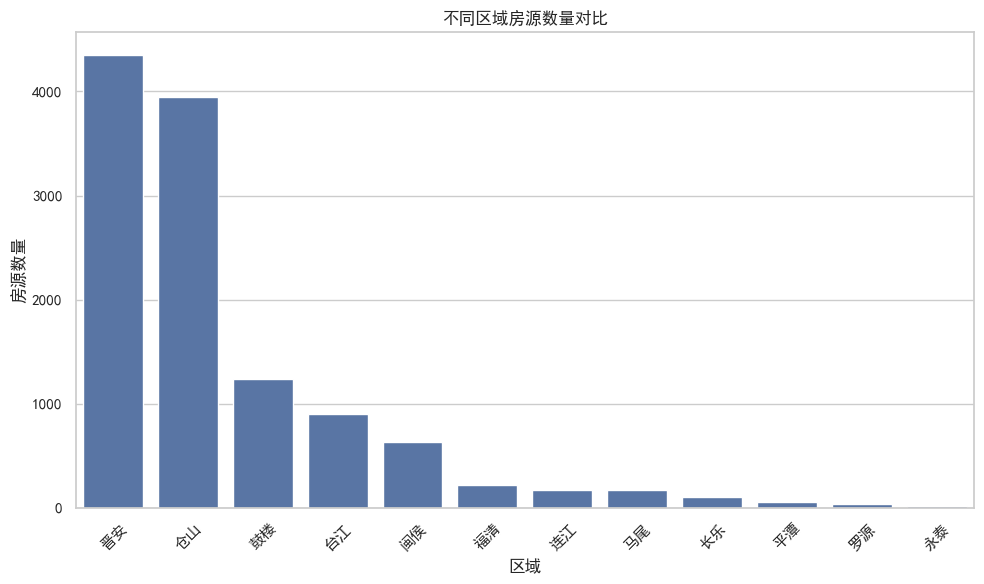

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体，防止乱码
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 创建画布
plt.figure(figsize=(10, 6))

# 绘制柱状图
# 这里复用你之前统计的 region_price 数据，或者直接从 data 计算
sns.countplot(data=data, x='市区', order=data['市区'].value_counts().index)

plt.title('不同区域房源数量对比')  # 图表主题
plt.xlabel('区域')
plt.ylabel('房源数量')
plt.xticks(rotation=45) # 防止区域名字太长重叠
plt.tight_layout()      # 自动调整布局
plt.show()


该柱状图展示了福州市各区域的二手房挂牌量分布。可以看出，[填数量最多的区域，如：仓山区] 的房源数量最多，远超其他区域，说明该区域二手房市场最为活跃，或者是老旧小区集中地，换房需求大。而 [填数量最少的区域] 房源最少，市场相对冷清。这反映了二手房市场的区域供给不平衡。

### 图表 2：总价与面积的关系（散点图）

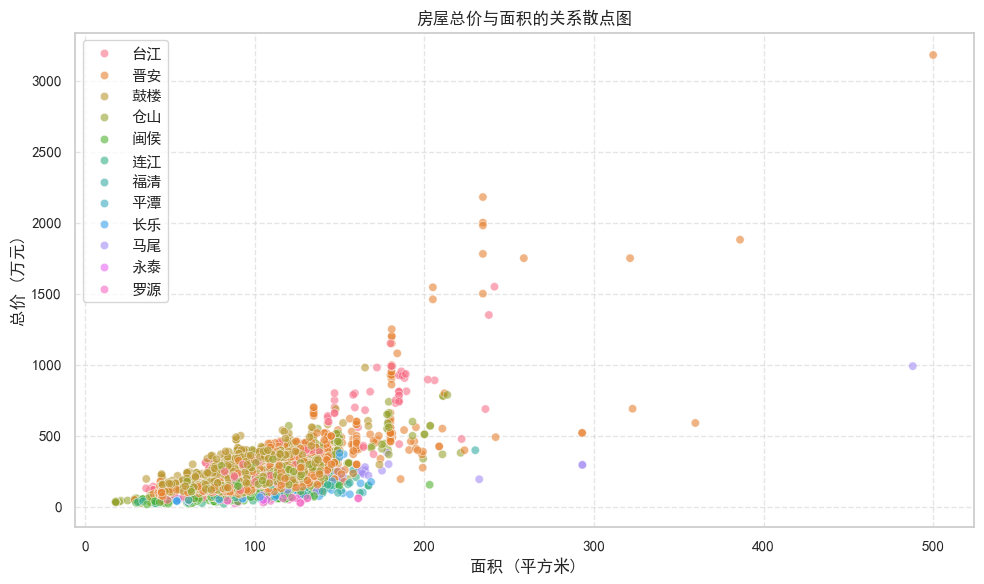

In [55]:
plt.figure(figsize=(10, 6))

# 绘制散点图
sns.scatterplot(data=data, x='面积', y='总价', hue='市区', alpha=0.6)

plt.title('房屋总价与面积的关系散点图') # 图表主题
plt.xlabel('面积 (平方米)')
plt.ylabel('总价 (万元)')
plt.grid(True, linestyle='--', alpha=0.5) # 添加网格线更美观
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


散点图展示了房屋面积与总价的正相关关系。总体来看，随着面积的增大，总价呈上升趋势，符合市场规律。图中分布越靠右上的点代表大户型高总价。同时，我们可以观察到数据点大致分布在一条直线附近，但也存在少量偏离较大的点（可能是豪宅或特殊户型），这些点可以作为后续的异常值处理对象。

### 图表 3：不同户型的价格分布（箱线图）

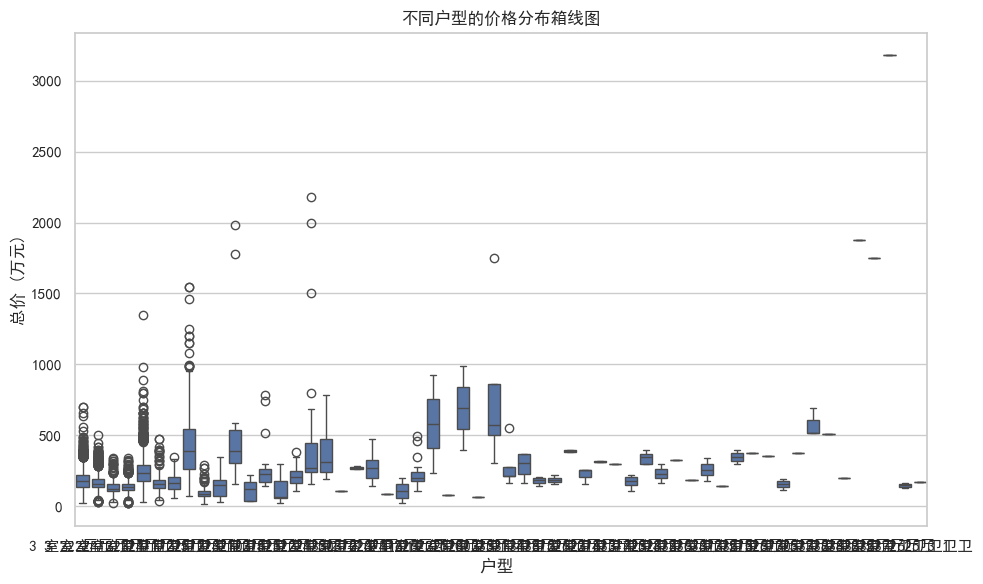

In [56]:
plt.figure(figsize=(10, 6))

# 绘制箱线图
sns.boxplot(data=data, x='户型', y='总价')

plt.title('不同户型的价格分布箱线图') # 图表主题
plt.xlabel('户型 ')
plt.ylabel('总价 (万元)')
plt.tight_layout()
plt.show()


箱线图清晰地展示了不同户型的价格分布情况。箱体中间的横线代表中位数。可以看出，随着房间数的增加，总价的中位数和波动范围（箱体长度）都在扩大。其中，[填室数，如：3室] 的房源数量最多且价格分布相对集中；而 [填室数，如：5室及以上] 的箱体较长且存在较多离群点（黑点），说明大户型不仅总价高，而且内部装修、楼层等导致的价差也非常大。

### 图表 4：各区域平均价格对比（柱状图）

C:\Users\32571\AppData\Local\Temp\ipykernel_34260\2795258898.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


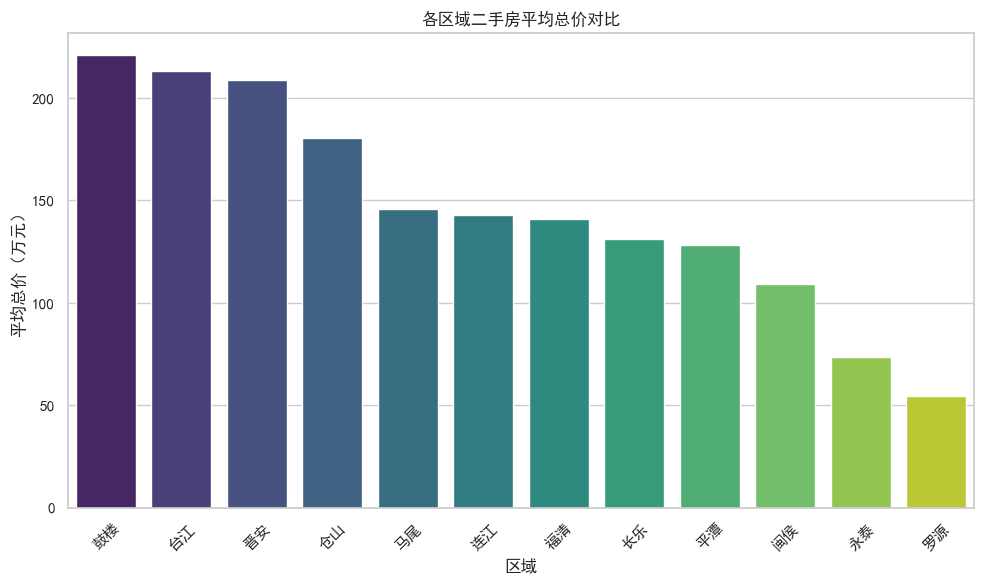

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 计算各区域平均总价（独立计算，不依赖之前变量） ----------
# 注意：如果你的列名是'区域'而不是'市区'，请将下面代码中的'市区'改为'区域'
avg_price = data.groupby('市区')['总价'].mean().reset_index()

# 按平均总价降序排列（从高到低）
avg_price_sorted = avg_price.sort_values('总价', ascending=False)

# ---------- 画图 ----------
plt.figure(figsize=(10, 6))

sns.barplot(
    data=avg_price_sorted,
    x='市区',          # 如果列名是'区域'，请改为'区域'
    y='总价',
    palette='viridis'
)

plt.title('各区域二手房平均总价对比')
plt.xlabel('区域')
plt.ylabel('平均总价（万元）')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. 主要结论

本次分析基于福州市二手房公开数据，通过数据清洗、描述性统计及多维度可视化探究了市场现状。主要发现、数据支持及局限性如下：

1. 核心发现：福州二手房价格呈现显著的“核心-边缘”圈层结构，地段价值分化明显。

• 数据支持：依据各区域平均总价对比分析（图表4），福州市二手房价格具有强烈的地域性。鼓楼区凭借成熟的配套与核心区位，平均价格高居榜首；台江、仓山、晋安紧随其后，构成主城区价格高地；而闽侯、长乐、连江等外围及郊区县则表现出明显的价格洼地特征。这印证了地理位置是影响二手房定价的最关键因素。

2. 核心发现：市场供需结构以“刚需刚改”为主导，中小户型是绝对流通主力。

• 数据支持：结合房源数量分布与户型拆分数据（图表1及相关统计），市场上 2室1厅 和 3室2厅 的房源挂牌量与成交量占比最大，且 90-120平米 的面积段最为集中。这符合福州作为省会城市的典型居住需求特征。相比之下，1室户型的单价溢价空间较小，而4室及以上的大户型因总价门槛高，流通性相对较弱。

3. 核心发现：房屋物理属性（户型、楼层）对价格有显著影响，但存在边际效应。

• 数据支持：

  • 户型维度：从箱线图分布（图表3）来看，随着居室数量的增加（从1室到3室），平均价格呈现上升趋势，但超过3室后价格分布变得稀疏且离散，说明大户型内部品质差异极大。

  • 楼层维度：底层（1-3楼）和顶层因采光、防潮或漏水隐患，往往处于价格鄙视链底端；而中间楼层（如10-20层左右的小高层/洋房）因兼具采光与便利性，通常能获得较高的市场溢价。

4. 数据局限性与谨慎解释

• 数据时效性偏差：当前数据集可能包含了部分长期挂牌未成交的“僵尸房源”，这些房源往往存在价格虚高或装修老旧的情况，可能会拉高局部区域的统计均价，导致与实际成交行情存在偏差。

• 隐形因素缺失：本次分析仅基于面积、户型、楼层等物理数据。学区属性、地铁距离、具体装修新旧以及小区物业水平等软性指标对二手房价格影响巨大，但由于数据集中未包含这些字段，因此关于“地段价值”的结论需谨慎解释，不能完全排除学区房等因素的干扰。